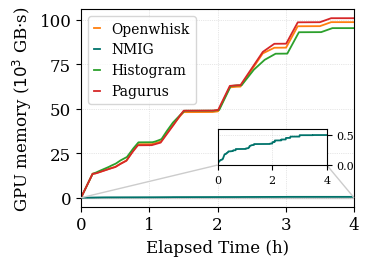

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib as mpl

first_invocation_bursty = 33.14
mpl.rcParams['font.family'] = 'DejaVu Serif'

experiments = [
    {"id": "exp_20250625_014444", "name": "Openwhisk"},
    {"id": "exp_20250625_071954", "name": "NMIG"},
    {"id": "exp_20250624_210136", "name": "Histogram"},
    {"id": "exp_20250624_165438", "name": "Pagurus"},
]

color_map = {
    "NMIG": "#00736b",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728",
}

MB_TO_GB = 1024.0
aligned_results = {}

for exp in experiments:
    fn = pd.read_csv(f"../results/{exp['id']}/results_updated.csv")
    df = pd.read_csv(f"../results/{exp['id']}/gpu_usage.csv")

    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_bursty * 1000

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('s')

    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['gb'] = df_avg['Avg_GPU_Memory_MB'] / MB_TO_GB

    mem_per_second = (
        df_avg.groupby('second_level_datetime')['gb']
              .sum()
              .reset_index(name='gb_per_second')
    )

    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    mem_per_second['relative_seconds'] = (
        (mem_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    mem_per_second = mem_per_second[mem_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    max_sec = mem_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    mem_per_second = full_sec.merge(mem_per_second, on='relative_seconds', how='left')
    mem_per_second['gb_per_second'] = mem_per_second['gb_per_second'].fillna(0)

    mem_per_second['cumulative_gbs'] = mem_per_second['gb_per_second'].cumsum()
    mem_per_second['relative_hours'] = mem_per_second['relative_seconds'] / 3600

    # pad to full 4 hours
    t_target = 4 * 3600
    if mem_per_second['relative_seconds'].max() < t_target:
        last_val = mem_per_second['cumulative_gbs'].iloc[-1]
        extra = pd.DataFrame({
            'relative_seconds': [t_target],
            'gb_per_second': [0],
            'cumulative_gbs': [last_val],
            'relative_hours': [t_target / 3600],
        })
        mem_per_second = pd.concat([mem_per_second, extra], ignore_index=True)

    aligned_results[exp['name']] = mem_per_second

# ---------- Plotting ----------
plt.figure(figsize=(3.5, 2.5))
ax = plt.gca()

for name, df in aligned_results.items():
    ax.plot(
        df['relative_hours'],
        df['cumulative_gbs'] / 1000.0,          # plot in 10^3 GB·s
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),
        marker='',
    )

ax.set_xlabel('Elapsed Time (h)', fontsize=12)
ax.set_ylabel(r'GPU memory ($10^3$ GB$\cdot$s)', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=10, handlelength=0.5)
ax.grid(linestyle=':', linewidth=0.5, alpha=0.6)
ax.set_xlim(0, 4)

# inset zoom for NMIG (small nonzero range)
axins = inset_axes(ax, width="80%", height="30%",
                   bbox_to_anchor=(0.45, 0.001, 0.5, 0.6),
                   bbox_transform=ax.transAxes,
                   loc='center')

for name, df in aligned_results.items():
    axins.plot(
        df['relative_hours'],
        df['cumulative_gbs'] / 1000.0,
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),
        marker='',
    )

axins.set_xlim(0, 4)
axins.set_ylim(0, 0.6)                 # 600 GB·s = 0.6 in 10^3 units (bursty)
axins.grid(linestyle=':', linewidth=0.5, alpha=0.6)
axins.tick_params(labelsize=8)
axins.yaxis.set_label_position("right")  # move inset ticks to the right
axins.yaxis.tick_right()

mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.8")

# explicit margins so the y-label is not clipped
plt.subplots_adjust(left=0.19, bottom=0.18, right=0.97, top=0.97)


plt.savefig('graphs_images/new_gpu_mem_bursty.jpg', dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()

In [11]:
aligned_results['Openwhisk']

,relative_seconds,second_level_datetime,gb_per_second,cumulative_gbs,relative_hours
0,0,2025-06-24 16:45:50,16.976562,16.976562,0.000000
1,0,2025-06-24 16:45:51,18.121094,35.097656,0.000000
2,1,2025-06-24 16:45:52,19.252930,54.350586,0.000278
3,2,2025-06-24 16:45:53,21.038086,75.388672,0.000556
4,3,2025-06-24 16:45:54,22.341797,97.730469,0.000833
...,...,...,...,...,...
13191,13190,2025-06-24 20:25:41,3.798828,98773.429688,3.663889
13192,13191,2025-06-24 20:25:42,3.798828,98777.228516,3.664167
13193,13192,2025-06-24 20:25:43,3.798828,98781.027344,3.664444
13194,13193,2025-06-24 20:25:44,2.279297,98783.306641,3.664722
